In [5]:
!pip install prophet scikit-learn xgboost plotly seaborn statsmodels tensorflow folium --quiet

# PM Accelerator Mission

PM Accelerator aims to empower future professionals with real-world AI, data science, and product management experience through hands-on industry projects.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('/content/GlobalWeatherRepository.csv')
df.head()


,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,2024-05-16 13:15,26.6,79.8,Partly Cloudy,...,8.4,26.6,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55
1,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,2024-05-16 10:45,19.0,66.2,Partly cloudy,...,1.1,2.0,1,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,2024-05-16 09:45,23.0,73.4,Sunny,...,10.4,18.4,1,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55
3,Andorra,Andorra La Vella,42.50,1.52,Europe/Andorra,1715849100,2024-05-16 10:45,6.3,43.3,Light drizzle,...,0.7,0.9,1,1,06:31 AM,09:11 PM,02:12 PM,03:31 AM,Waxing Gibbous,55
4,Angola,Luanda,-8.84,13.23,Africa/Luanda,1715849100,2024-05-16 09:45,26.0,78.8,Partly cloudy,...,183.4,262.3,5,10,06:12 AM,05:55 PM,01:17 PM,12:38 AM,Waxing Gibbous,55


In [8]:

df.tail()

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
141308,Venezuela,Caracas,10.5000,-66.9167,America/Caracas,1778740200,2026-05-14 02:30,18.5,65.3,Patchy rain nearby,...,13.55,17.75,1,2,06:06 AM,06:42 PM,03:56 AM,04:39 PM,Waning Crescent,10
141309,Vietnam,Hanoi,21.0333,105.8500,Asia/Bangkok,1778740200,2026-05-14 13:30,37.0,98.6,Sunny,...,82.15,84.45,4,10,05:20 AM,06:26 PM,02:57 AM,03:50 PM,Waning Crescent,14
141310,Yemen,Sanaa,15.3547,44.2067,Asia/Aden,1778740200,2026-05-14 09:30,22.5,72.5,Sunny,...,24.15,125.65,2,3,05:35 AM,06:24 PM,03:15 AM,04:02 PM,Waning Crescent,12
141311,Zambia,Lusaka,-15.4167,28.2833,Africa/Lusaka,1778740200,2026-05-14 08:30,20.5,68.9,Sunny,...,5.85,5.95,1,1,06:21 AM,05:46 PM,03:40 AM,03:40 PM,Waning Crescent,12
141312,Zimbabwe,Harare,-17.8178,31.0447,Africa/Harare,1778740200,2026-05-14 08:30,19.3,66.8,Sunny,...,24.75,25.15,2,3,06:13 AM,05:31 PM,03:31 AM,03:27 PM,Waning Crescent,12


In [9]:
print(df.shape)

(141313, 41)


In [10]:
# Column info
df.info()

# Missing values
missing = df.isnull().sum()
missing[missing > 0]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 141313 entries, 0 to 141312
Data columns (total 41 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   country                       141313 non-null  object 
 1   location_name                 141313 non-null  object 
 2   latitude                      141313 non-null  float64
 3   longitude                     141313 non-null  float64
 4   timezone                      141313 non-null  object 
 5   last_updated_epoch            141313 non-null  int64  
 6   last_updated                  141313 non-null  object 
 7   temperature_celsius           141313 non-null  float64
 8   temperature_fahrenheit        141313 non-null  float64
 9   condition_text                141313 non-null  object 
 10  wind_mph                      141313 non-null  float64
 11  wind_kph                      141313 non-null  float64
 12  wind_degree                   141313 non-nul

,0


In [11]:
df.isnull().sum()

,0
country,0
location_name,0
latitude,0
longitude,0
timezone,0
last_updated_epoch,0
last_updated,0
temperature_celsius,0
temperature_fahrenheit,0
condition_text,0


In [12]:
from sklearn.preprocessing import StandardScaler

# 1. Convert last_updated to datetime
df['last_updated'] = pd.to_datetime(df['last_updated'], errors='coerce')

# 2. Drop rows where last_updated is NaT (critical for time series)
df.dropna(subset=['last_updated'], inplace=True)

# 3. Sort by date
df.sort_values('last_updated', inplace=True)
df.reset_index(drop=True, inplace=True)

# 4. Handle missing numeric columns: forward fill (temporal) then median
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(method='ffill').fillna(df[numeric_cols].median())

# 5. Outlier handling (cap at 99th percentile for temperature_celsius)
for col in ['temperature_celsius', 'precip_mm', 'humidity']:
    upper = df[col].quantile(0.99)
    lower = df[col].quantile(0.01)
    df[col] = df[col].clip(lower, upper)

# 6. Normalize (scale) selected features for models that need it
scaler = StandardScaler()
features_to_scale = ['temperature_celsius', 'humidity', 'pressure_mb', 'wind_kph', 'precip_mm']
df_scaled = df.copy()
df_scaled[features_to_scale] = scaler.fit_transform(df[features_to_scale])

print("Cleaning done. Remaining rows:", df.shape[0])

Cleaning done. Remaining rows: 141313


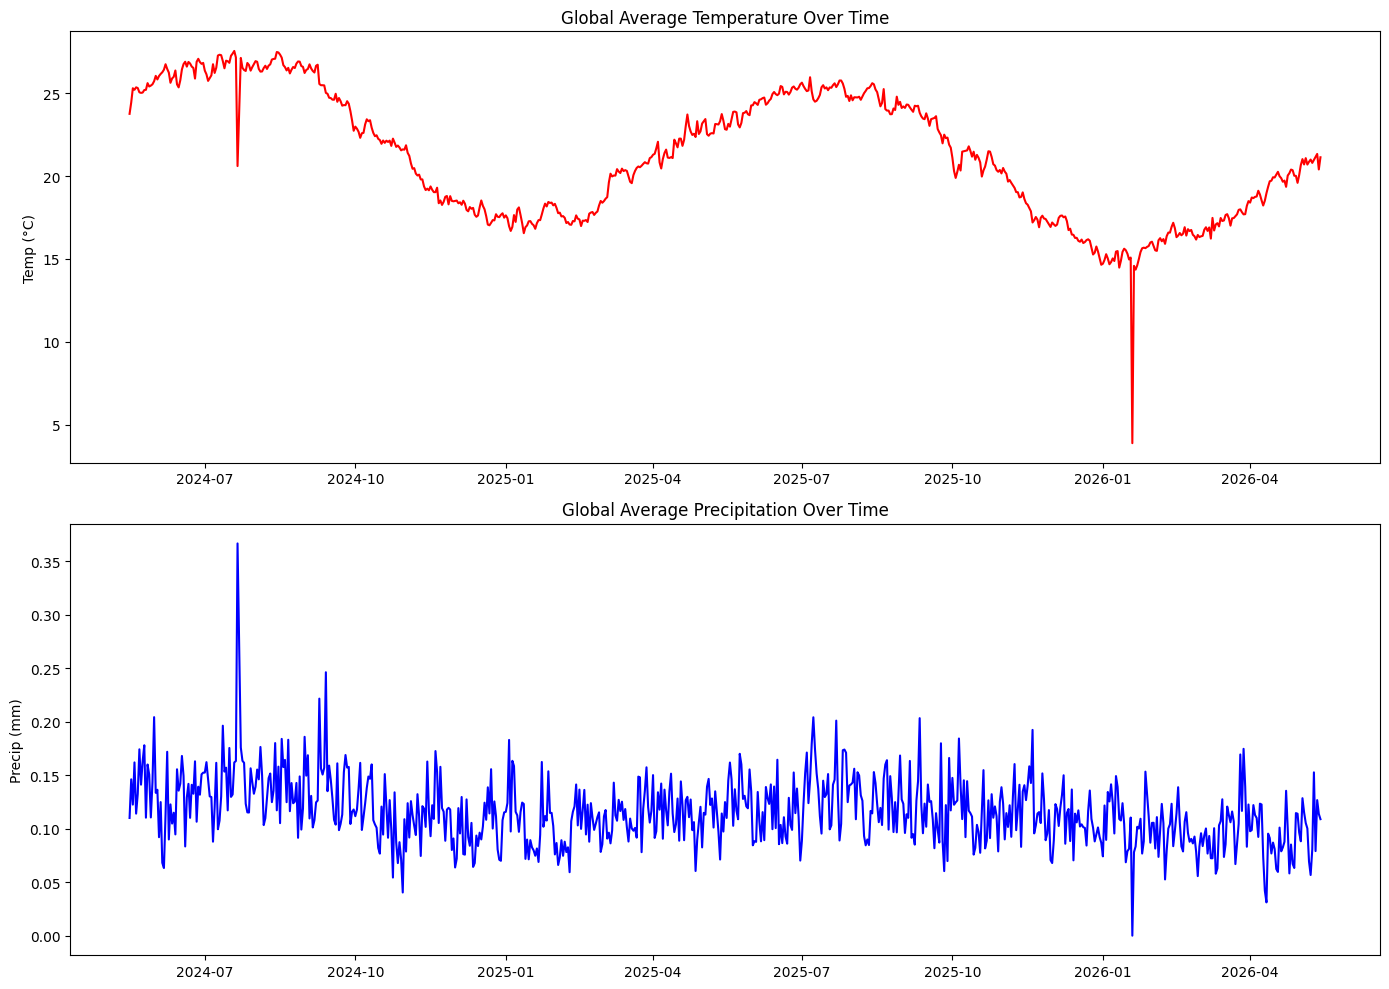

In [13]:
# Temperature & precipitation over time (global average per day)
daily_avg = df.groupby(df['last_updated'].dt.date)[['temperature_celsius', 'precip_mm']].mean()

fig, ax = plt.subplots(2, 1, figsize=(14, 10))
ax[0].plot(daily_avg.index, daily_avg['temperature_celsius'], color='red')
ax[0].set_title('Global Average Temperature Over Time')
ax[0].set_ylabel('Temp (°C)')
ax[1].plot(daily_avg.index, daily_avg['precip_mm'], color='blue')
ax[1].set_title('Global Average Precipitation Over Time')
ax[1].set_ylabel('Precip (mm)')
plt.tight_layout()
plt.show()



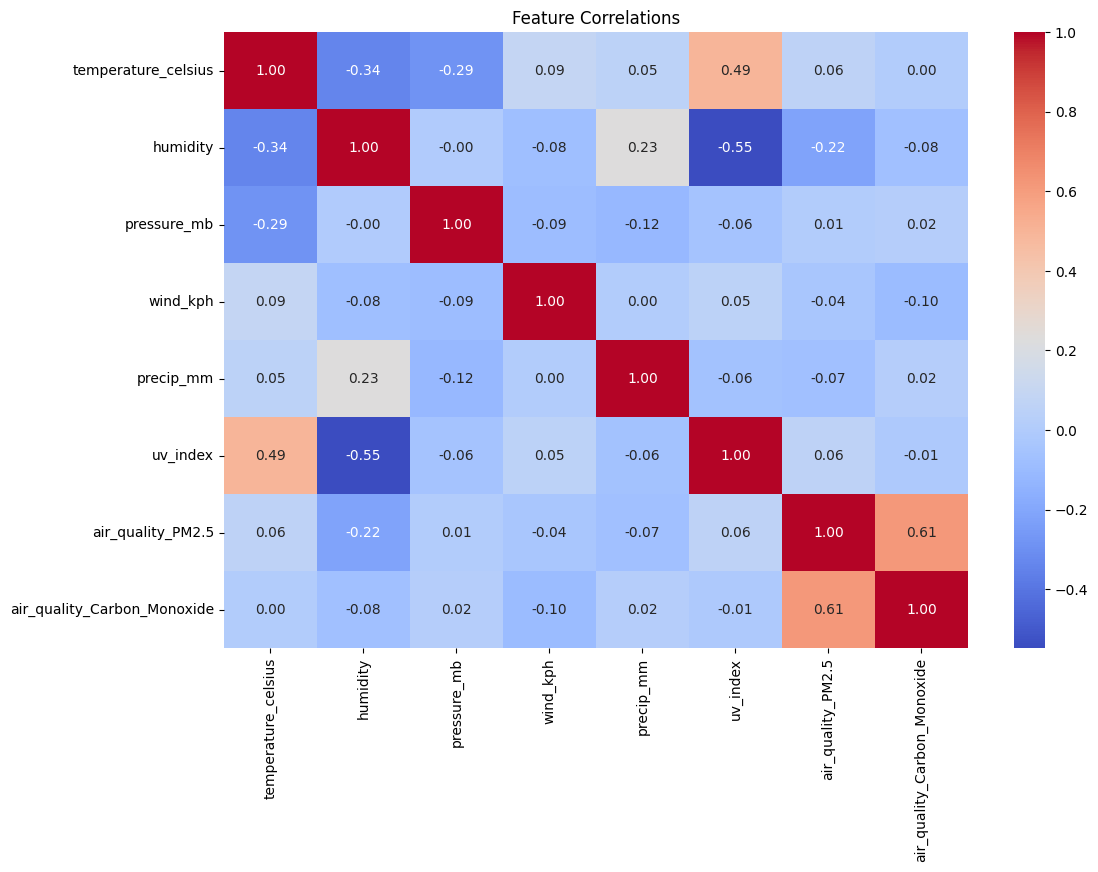

In [14]:
# Correlation heatmap
plt.figure(figsize=(12, 8))
corr = df[['temperature_celsius', 'humidity', 'pressure_mb', 'wind_kph', 'precip_mm',
           'uv_index', 'air_quality_PM2.5', 'air_quality_Carbon_Monoxide']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlations')
plt.show()

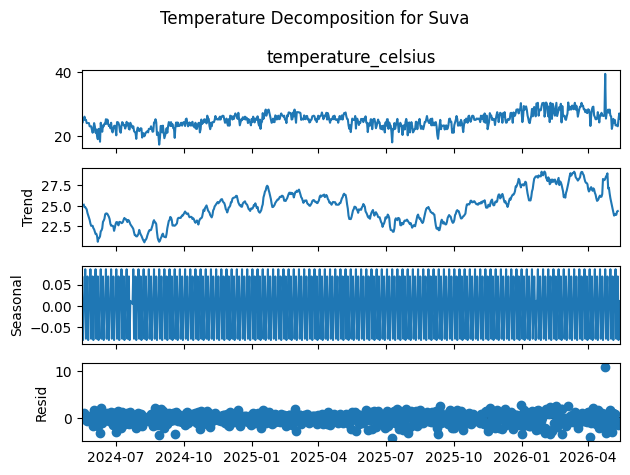

In [15]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

# Select a city with most data points
top_city = df['location_name'].value_counts().index[0]
city_df = df[df['location_name'] == top_city].copy()
city_df.set_index('last_updated', inplace=True)
city_ts = city_df['temperature_celsius'].resample('D').mean().dropna()

# Decompose (additive)
decomp = seasonal_decompose(city_ts, model='additive', period=7)  # weekly seasonality
decomp.plot()
plt.suptitle(f'Temperature Decomposition for {top_city}')
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


Holt-Winters - MAE: 1.71°C, RMSE: 2.95°C


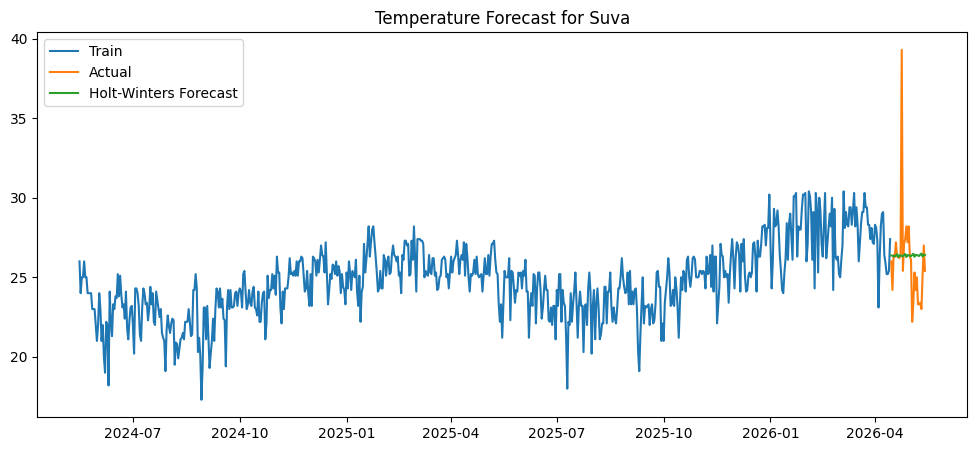

In [16]:
from statsmodels.tsa.api import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np

# Use last 30 days as test
train = city_ts[:-30]
test = city_ts[-30:]

model_hw = ExponentialSmoothing(train, seasonal_periods=7, trend='add', seasonal='add')
fit_hw = model_hw.fit()
pred_hw = fit_hw.forecast(len(test))

# Evaluation
mae_hw = mean_absolute_error(test, pred_hw)
rmse_hw = np.sqrt(mean_squared_error(test, pred_hw))
print(f"Holt-Winters - MAE: {mae_hw:.2f}°C, RMSE: {rmse_hw:.2f}°C")

plt.figure(figsize=(12,5))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Actual')
plt.plot(test.index, pred_hw, label='Holt-Winters Forecast')
plt.title(f'Temperature Forecast for {top_city}')
plt.legend()
plt.show()

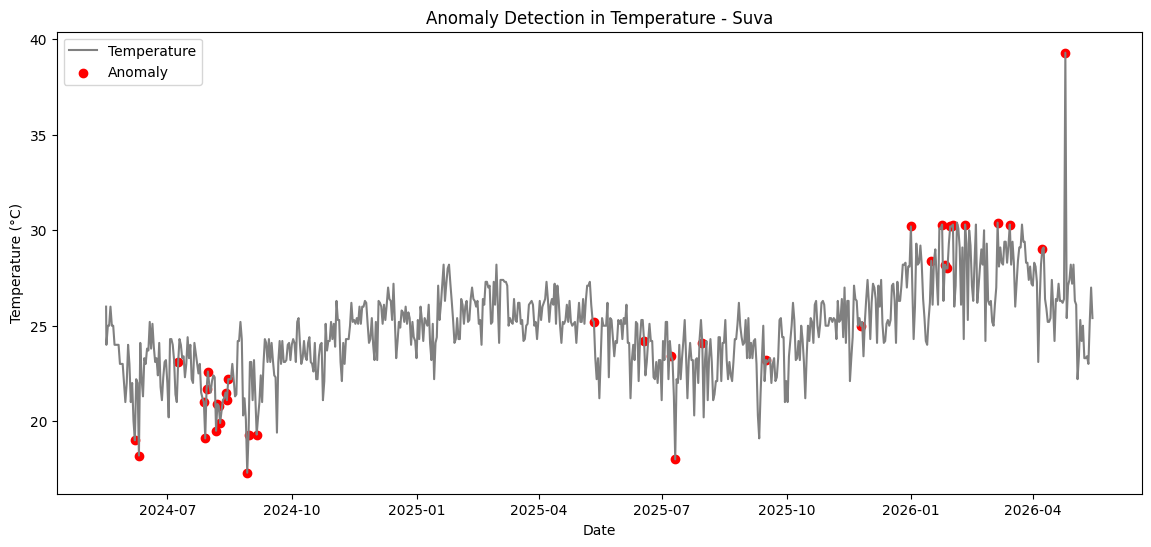

In [17]:
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt

# Detect anomalies in temperature for the selected city
features_anom = city_df[['temperature_celsius', 'humidity', 'pressure_mb']].dropna()
iso_forest = IsolationForest(contamination=0.05, random_state=42)
anomalies = iso_forest.fit_predict(features_anom)
city_df['anomaly'] = anomalies

# Plot anomalies
plt.figure(figsize=(14,6))
plt.plot(city_df.index, city_df['temperature_celsius'], label='Temperature', color='gray')
anom_points = city_df[city_df['anomaly'] == -1]
plt.scatter(anom_points.index, anom_points['temperature_celsius'], color='red', label='Anomaly')
plt.title(f'Anomaly Detection in Temperature - {top_city}')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.show()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
INFO:prophet:Dis

ARIMA      MAE: 1.70°C, RMSE: 2.93°C
Prophet    MAE: 3.91°C, RMSE: 4.40°C
Holt-Winters MAE: 1.71°C, RMSE: 2.95°C
Ensemble   MAE: 2.20°C, RMSE: 3.21°C


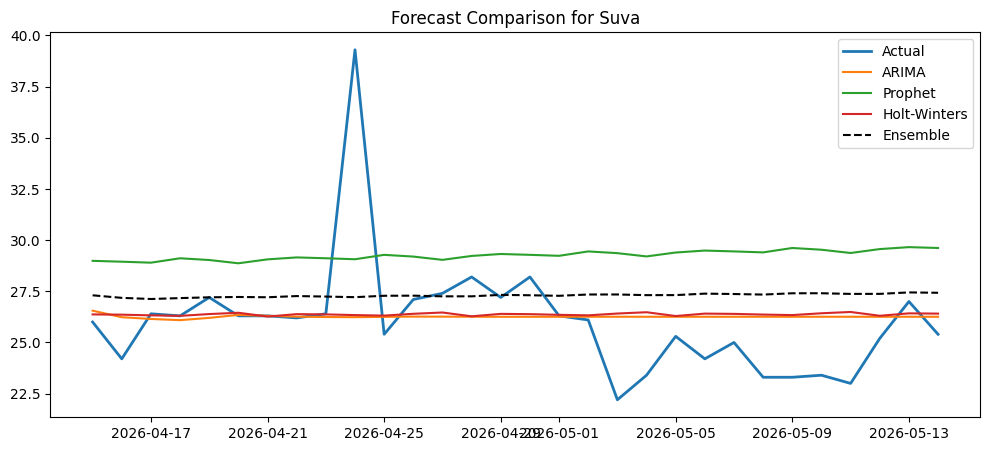

In [18]:
from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Prepare data for Prophet (needs ds, y)
prophet_df = city_ts.reset_index().rename(columns={'last_updated':'ds', 'temperature_celsius':'y'})

# ARIMA
model_arima = ARIMA(train, order=(5,1,0))
fit_arima = model_arima.fit()
arima_forecast_values = fit_arima.forecast(len(test))
pred_arima = pd.Series(arima_forecast_values.values, index=test.index) # Align index

# Prophet
model_prophet = Prophet(daily_seasonality=True)
model_prophet.fit(prophet_df[prophet_df['ds'] < test.index[0]])
future = model_prophet.make_future_dataframe(periods=len(test))
forecast_prophet = model_prophet.predict(future)
pred_prophet = forecast_prophet.set_index('ds').loc[test.index, 'yhat']

# Holt-Winters (pred_hw was generated in the previous cell, need to re-align its index)
# Assuming fit_hw is still available from the previous cell, or re-run its creation.
# For robustness, recalculate or ensure proper re-indexing.
# If fit_hw needs to be defined here for sure, it would be:
# model_hw = ExponentialSmoothing(train, seasonal_periods=7, trend='add', seasonal='add')
# fit_hw = model_hw.fit()
hw_forecast_values = fit_hw.forecast(len(test))
pred_hw = pd.Series(hw_forecast_values.values, index=test.index) # Align index

# Evaluate
def evaluate(name, pred):
    mae = mean_absolute_error(test, pred)
    rmse = np.sqrt(mean_squared_error(test, pred))
    print(f"{name:10} MAE: {mae:.2f}°C, RMSE: {rmse:.2f}°C")
    return mae, rmse

evaluate("ARIMA", pred_arima)
evaluate("Prophet", pred_prophet)
evaluate("Holt-Winters", pred_hw)

# Simple Ensemble: average of the three
pred_ensemble = (pred_arima + pred_prophet + pred_hw) / 3
evaluate("Ensemble", pred_ensemble)

# Plot comparison
plt.figure(figsize=(12,5))
plt.plot(test.index, test, label='Actual', linewidth=2)
plt.plot(test.index, pred_arima, label='ARIMA')
plt.plot(test.index, pred_prophet, label='Prophet')
plt.plot(test.index, pred_hw, label='Holt-Winters')
plt.plot(test.index, pred_ensemble, label='Ensemble', linestyle='--', color='black')
plt.title(f'Forecast Comparison for {top_city}')
plt.legend()
plt.show()

Ensemble MAE: 2.196710352788433
Ensemble RMSE: 3.2052583961038703


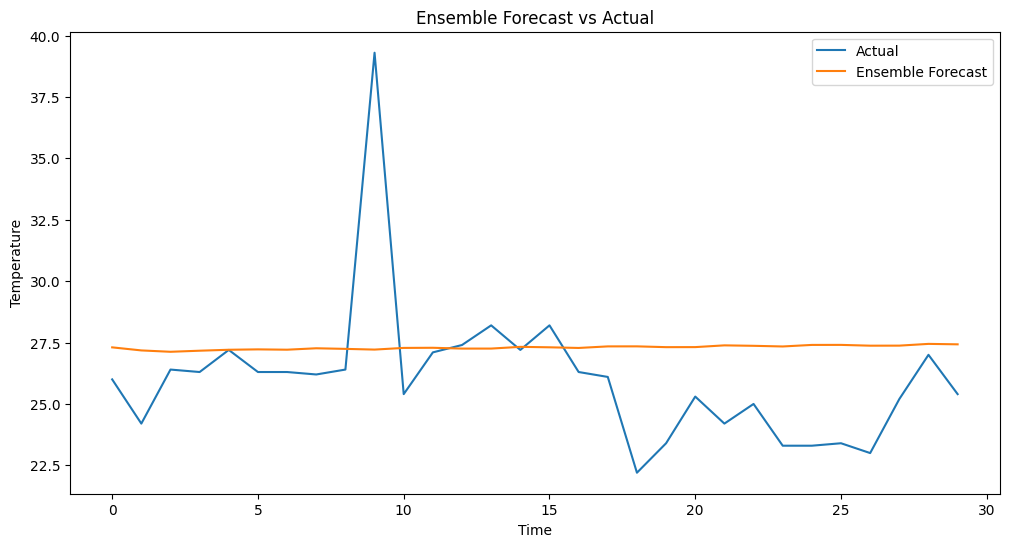

In [22]:
# ==============================
# Ensemble Forecasting
# ==============================

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

# Make sure forecasts are same length
min_len = min(
    len(pred_hw),
    len(pred_arima),
    len(pred_prophet)
)

# Convert forecasts to arrays
hw_vals = np.array(pred_hw[:min_len])
arima_vals = np.array(pred_arima[:min_len])
prophet_vals = np.array(pred_prophet[:min_len])

# Ensemble prediction using average
ensemble_forecast = (
    hw_vals +
    arima_vals +
    prophet_vals
) / 3

# Actual test values
actual_vals = np.array(test[:min_len])

# Evaluation
ensemble_mae = mean_absolute_error(actual_vals, ensemble_forecast)
ensemble_rmse = np.sqrt(mean_squared_error(actual_vals, ensemble_forecast))

print("Ensemble MAE:", ensemble_mae)
print("Ensemble RMSE:", ensemble_rmse)

# Plot
plt.figure(figsize=(12,6))

plt.plot(actual_vals, label='Actual')
plt.plot(ensemble_forecast, label='Ensemble Forecast')

plt.title("Ensemble Forecast vs Actual")
plt.xlabel("Time")
plt.ylabel("Temperature")

plt.legend()
plt.show()

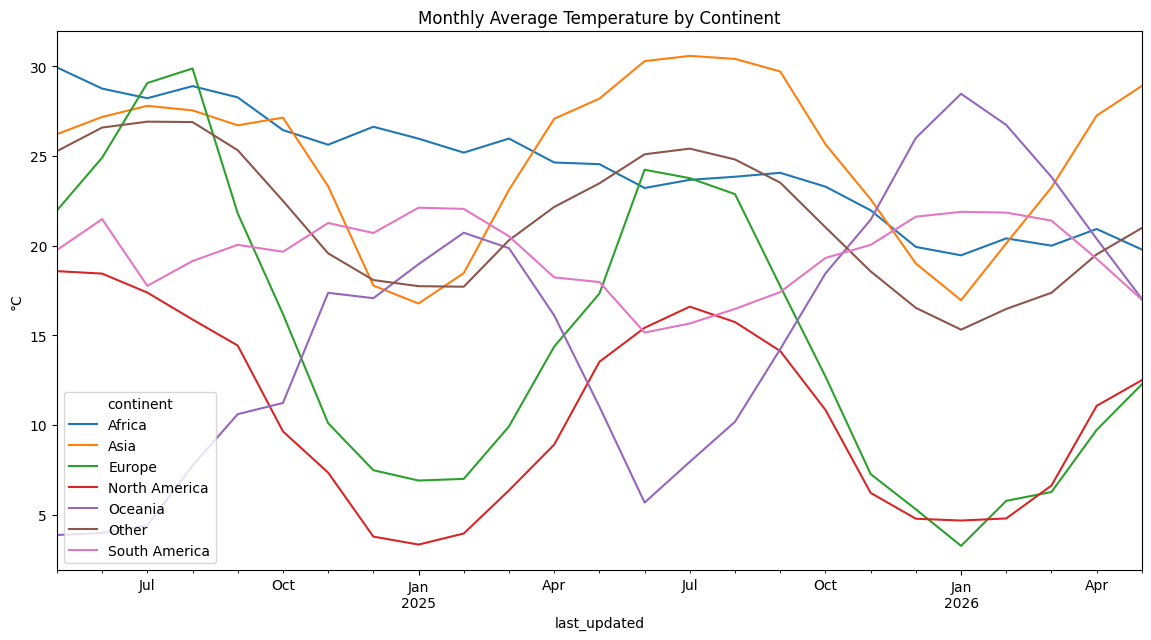

In [25]:
# Map country to continent (simple mapping or use pycountry_convert; here simplified)
# For demo, assume you have 'continent' column; if not, create from known country list.
# If missing, we'll use countries and group.

# Let's create a continent mapping for major countries (add more as needed)
country_continent = {
    'United States': 'North America', 'Canada': 'North America', 'Mexico': 'North America',
    'Brazil': 'South America', 'Argentina': 'South America',
    'UK': 'Europe', 'Germany': 'Europe', 'France': 'Europe', 'Italy': 'Europe', 'Spain': 'Europe',
    'China': 'Asia', 'India': 'Asia', 'Japan': 'Asia', 'Indonesia': 'Asia',
    'Australia': 'Oceania',
    'South Africa': 'Africa', 'Nigeria': 'Africa', 'Egypt': 'Africa'
}
df['continent'] = df['country'].map(country_continent).fillna('Other')

# Long-term temperature trend per continent
cont_temp = df.groupby([df['last_updated'].dt.to_period('M'), 'continent'])['temperature_celsius'].mean().unstack()
cont_temp.plot(figsize=(14,7))
plt.title('Monthly Average Temperature by Continent')
plt.ylabel('°C')
plt.show()

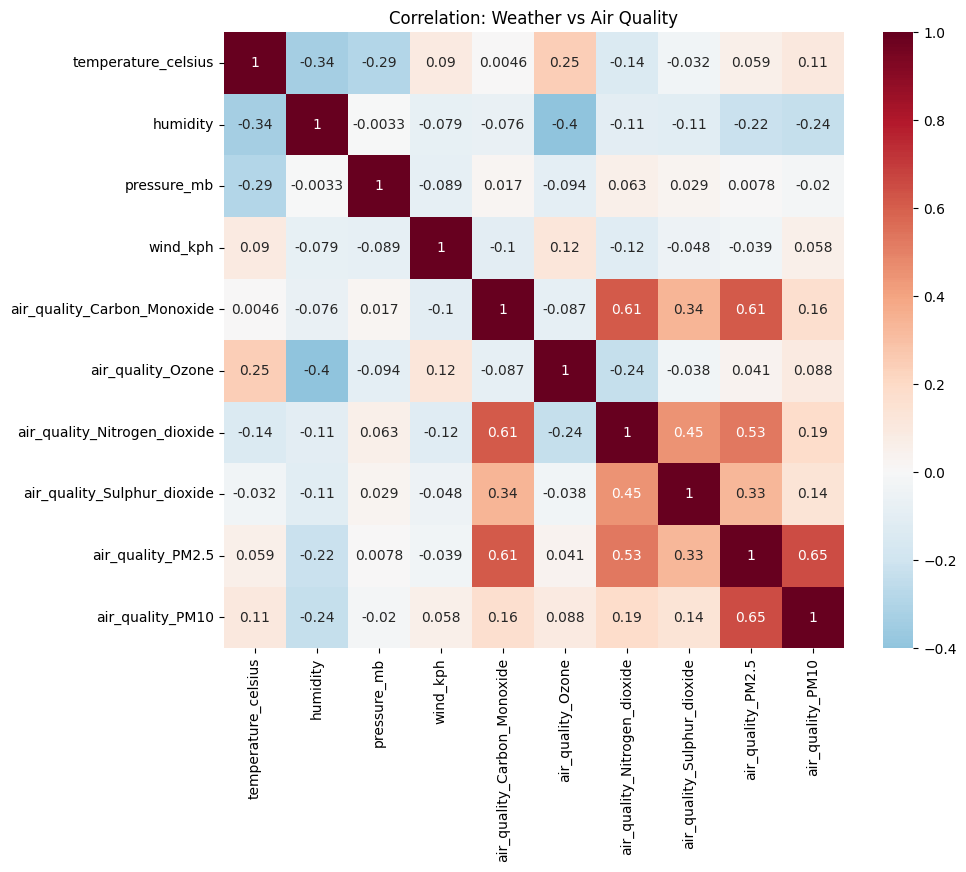

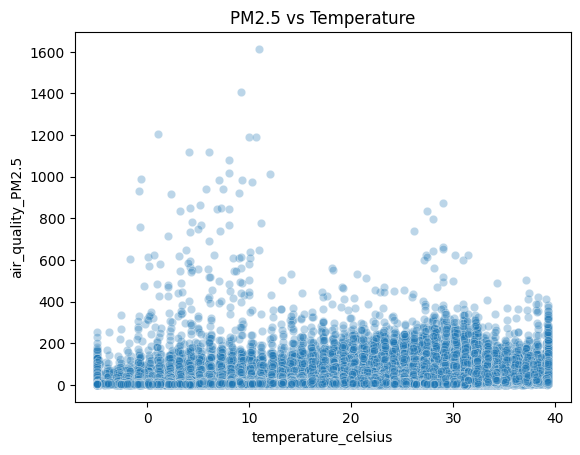

In [26]:
# Correlation between air quality pollutants and temperature/humidity
air_cols = ['air_quality_Carbon_Monoxide', 'air_quality_Ozone', 'air_quality_Nitrogen_dioxide',
            'air_quality_Sulphur_dioxide', 'air_quality_PM2.5', 'air_quality_PM10']
weather_cols = ['temperature_celsius', 'humidity', 'pressure_mb', 'wind_kph']

corr_matrix = df[weather_cols + air_cols].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0)
plt.title('Correlation: Weather vs Air Quality')
plt.show()

# Example: PM2.5 vs Temperature scatter
sns.scatterplot(data=df, x='temperature_celsius', y='air_quality_PM2.5', alpha=0.3)
plt.title('PM2.5 vs Temperature')
plt.show()

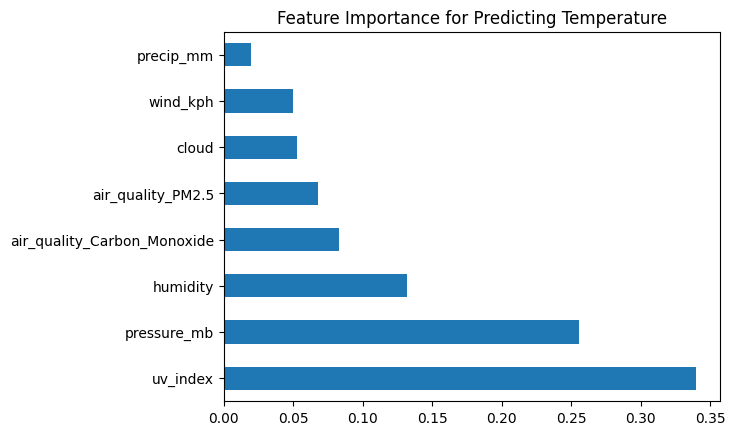

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import pandas as pd
import matplotlib.pyplot as plt

# Prepare features (excluding target and non-numeric)
feature_cols = ['humidity', 'pressure_mb', 'wind_kph', 'precip_mm', 'cloud', 'uv_index',
                'air_quality_PM2.5', 'air_quality_Carbon_Monoxide']
X = df[feature_cols].dropna()
y = df.loc[X.index, 'temperature_celsius']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

importance = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
importance.plot(kind='barh', title='Feature Importance for Predicting Temperature')
plt.show()

In [30]:
import plotly.express as px

# Group by coordinates to avoid overlapping
map_data = df.groupby(['latitude', 'longitude'])[['temperature_celsius', 'air_quality_PM2.5']].mean().reset_index()

# Ensure that the 'size' property receives non-negative values
# Use absolute value of temperature for marker size. Plotly's size parameter expects non-negative values.
map_data['abs_temperature_celsius'] = np.abs(map_data['temperature_celsius'])

fig = px.scatter_geo(map_data, lat='latitude', lon='longitude',
                     size='abs_temperature_celsius', # Use the new absolute temperature column for size
                     color='temperature_celsius',    # Keep original temperature for color to show actual values
                     hover_name=map_data.index,
                     title='Global Average Temperature by Location',
                     color_continuous_scale='Viridis')
fig.show()

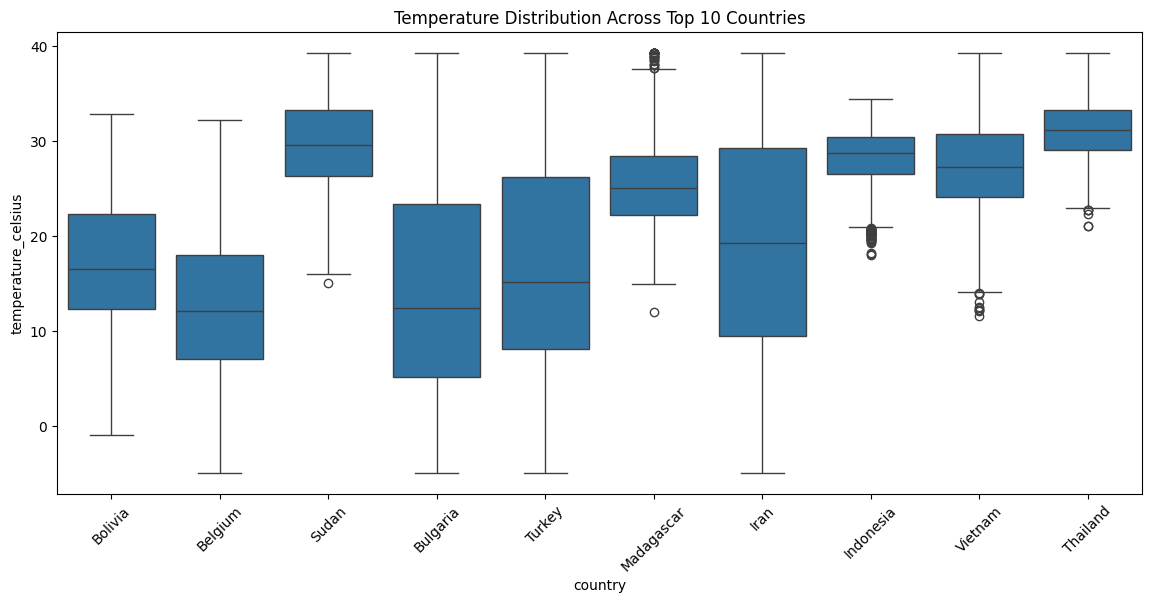

In [31]:
top_countries = df['country'].value_counts().head(10).index
df_top = df[df['country'].isin(top_countries)]

plt.figure(figsize=(14,6))
sns.boxplot(data=df_top, x='country', y='temperature_celsius')
plt.xticks(rotation=45)
plt.title('Temperature Distribution Across Top 10 Countries')
plt.show()